# 01 Synthetic Optimization

Research question: **Does DiagonalOptimiser provide advantages on difficult optimization landscapes?**

This notebook focuses on objective functions where curvature and poor conditioning are central:

- ill-conditioned quadratics with condition numbers 10, 100, 1000, 10000
- Rosenbrock variants
- optional nonconvex functions can be added only if they reveal meaningful differences

The optimizer algorithm is not modified. Timing wraps the full optimizer call, so finite-difference Hessian-vector products, Hessian sketches, eigendecomposition, and trust-region work are included.

In [13]:
from pathlib import Path
import csv
import json
import math
import subprocess
import sys
import time
from collections import defaultdict
from statistics import mean, stdev

import numpy as np

import matplotlib.pyplot as plt

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import Image, Markdown, display
except ImportError:
    def display(x):
        print(x)
    def Markdown(x):
        return x
    def Image(filename):
        return filename

REPO_ROOT = Path.cwd().resolve()
for candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (candidate / "optimizer").exists() and (candidate / "experiments").exists():
        REPO_ROOT = candidate
        break
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print(f"Repo root: {REPO_ROOT}")

Repo root: /content


## Run Or Load Results

In [14]:
OUTPUT_DIR = REPO_ROOT / "results" / "synthetic_optimization"
SMOKE_OUTPUT_DIR = REPO_ROOT / "results" / "synthetic_optimization_smoke"

# Keep this False for a quick notebook check. Set True for publication runs.
FULL_RUN = False

# If no full results exist, the notebook will generate a short smoke run automatically.
AUTO_RUN_SMOKE_IF_MISSING = True

FULL_SEEDS = "0,1,2,3,4"
FULL_MAX_ITER = 500
SMOKE_SEEDS = "0"
SMOKE_MAX_ITER = 50


def write_csv(path, rows):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        return
    fieldnames = sorted({key for row in rows for key in row})
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def write_json(path, data):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def project_to_ball(x, radius):
    norm = np.linalg.norm(x)
    return x if norm <= radius else x * (radius / (norm + 1e-12))


def symmetric_antisymmetric_split(B):
    return 0.5 * (B + B.T), 0.5 * (B - B.T)


def sa_rsvd_tr_optimizer(f, grad_f, x0, k=3, oversample=4, lr=1.0, max_iter=500, warmup_iters=30, max_step_norm=0.05, tol=1e-6):
    # Notebook-local copy of the repository algorithm for Colab/notebook-only runs.
    x = x0.copy()
    n = x.shape[0]
    losses = []
    S_ema = None
    U_prev = None
    R_tr = 1.0
    beta_S = 0.2
    drift_thresh = 0.5
    c_noise = 1.0
    lambda_min = 1e-3
    alpha_residual = 0.1
    antisymm_gate = 2.0
    alpha_fallback = 0.2

    for it in range(1, max_iter + 1):
        f_old = f(x)
        losses.append(f_old)
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        if it <= warmup_iters:
            step = -0.01 * g
            if np.linalg.norm(step) > max_step_norm:
                step *= max_step_norm / (np.linalg.norm(step) + 1e-12)
            x = x + step
            continue

        L = min(n, k + oversample)
        Omega = np.random.randn(n, L)
        eps_fd = 1e-4
        Y = np.zeros((n, L))
        for j in range(L):
            Y[:, j] = (grad_f(x + eps_fd * Omega[:, j]) - g) / eps_fd
        Q, _ = np.linalg.qr(Y)
        HQ = np.zeros((n, L))
        for j in range(L):
            HQ[:, j] = (grad_f(x + eps_fd * Q[:, j]) - g) / eps_fd
        B = Q.T @ HQ
        S, A = symmetric_antisymmetric_split(B)
        S_norm = np.linalg.norm(S, "fro") + 1e-12
        A_norm = np.linalg.norm(A, "fro")
        rho_antisymm = A_norm / S_norm
        S_ema = S if S_ema is None else (1 - beta_S) * S_ema + beta_S * S
        evals, W = np.linalg.eigh(S_ema)
        idx = np.argsort(evals)[::-1]
        evals, W = evals[idx], W[:, idx]
        k_eff = min(k, L)
        evals_k, W_k = evals[:k_eff], W[:, :k_eff]
        U = Q @ W_k
        if U_prev is not None:
            drift = np.linalg.norm(U @ U.T - U_prev @ U_prev.T, "fro")
            if drift > drift_thresh:
                alpha = drift_thresh / (drift + 1e-12)
                U, _ = np.linalg.qr((1 - alpha) * U_prev + alpha * U)
        U_prev = U.copy()
        damp_floor = max(c_noise * A_norm, lambda_min)
        evals_clamped = np.maximum(evals_k, damp_floor)
        if rho_antisymm > antisymm_gate:
            p = -alpha_fallback * g
        else:
            z = U.T @ g
            p = -U @ (z / evals_clamped) - alpha_residual * g
        step = project_to_ball(lr * p, max(R_tr / (1 + rho_antisymm), 1e-12))
        if np.linalg.norm(step) > max_step_norm:
            step *= max_step_norm / (np.linalg.norm(step) + 1e-12)
        x_trial = x + step
        f_new = f(x_trial)
        H_step = U @ (evals_k * (U.T @ step))
        m_pred = f_old + g @ step + 0.5 * (step @ H_step)
        denom = f_old - m_pred
        rho = 1.0 if abs(denom) < 1e-12 else (f_old - f_new) / denom
        if rho < 0.25:
            R_tr *= 0.5
        elif rho > 0.75:
            R_tr = min(1.5 * R_tr, 5.0)
        if rho > 0.0:
            x = x_trial
    return x, it, losses


def adam_optimizer(f, grad_f, x0, lr=0.002, max_iter=500):
    x = x0.copy(); m = np.zeros_like(x); v = np.zeros_like(x); losses = []
    for t in range(1, max_iter + 1):
        losses.append(f(x)); g = grad_f(x)
        m = 0.9 * m + 0.1 * g
        v = 0.999 * v + 0.001 * (g * g)
        x = x - lr * (m / (1 - 0.9 ** t)) / (np.sqrt(v / (1 - 0.999 ** t)) + 1e-8)
    return x, max_iter, losses


def sgd_optimizer(f, grad_f, x0, lr=0.001, max_iter=500):
    x = x0.copy(); v = np.zeros_like(x); losses = []
    for t in range(1, max_iter + 1):
        losses.append(f(x)); g = grad_f(x)
        v = 0.9 * v + 0.1 * g
        x = x - lr * v
    return x, max_iter, losses


def quadratic_problem(dim, condition_number, seed):
    rng = np.random.default_rng(seed)
    q, _ = np.linalg.qr(rng.normal(size=(dim, dim)))
    eigvals = np.geomspace(1.0, condition_number, dim)
    H = q @ np.diag(eigvals) @ q.T
    x0 = rng.normal(size=dim)
    return lambda x: 0.5 * float(x.T @ H @ x), lambda x: H @ x, x0


def rosenbrock_problem(seed):
    rng = np.random.default_rng(seed)
    x0 = np.array([-1.2, 1.0]) + 0.05 * rng.normal(size=2)
    def f(x):
        return float((1 - x[0]) ** 2 + 100.0 * (x[1] - x[0] ** 2) ** 2)
    def grad(x):
        return np.array([
            -2.0 * (1 - x[0]) - 400.0 * x[0] * (x[1] - x[0] ** 2),
            200.0 * (x[1] - x[0] ** 2),
        ])
    return f, grad, x0


def summarize(losses, elapsed, targets):
    out = {
        "final_loss": float(losses[-1]),
        "best_loss": float(min(losses)),
        "wall_time_sec": elapsed,
        "stable": all(math.isfinite(float(v)) for v in losses),
        "loss_auc_steps": float(np.trapezoid(losses, dx=1.0)) if len(losses) > 1 else 0.0,
    }
    for target in targets:
        hit = next((i + 1 for i, loss in enumerate(losses) if loss <= target), None)
        out[f"steps_to_loss_{target}"] = hit
    return out


def aggregate_rows(summaries):
    grouped = defaultdict(list)
    for row in summaries:
        grouped[(row["problem"], row["condition_number"], row["optimizer"])].append(row)
    target_keys = sorted({k for row in summaries for k in row if k.startswith("steps_to_loss_")})
    keys = ["final_loss", "best_loss", "wall_time_sec", "loss_auc_steps"] + target_keys
    out = []
    for (problem, cond, opt), rows in sorted(grouped.items()):
        agg = {"problem": problem, "condition_number": cond, "optimizer": opt, "runs": len(rows), "stable_runs": sum(r["stable"] for r in rows)}
        for key in keys:
            vals = [float(r[key]) for r in rows if r.get(key) is not None]
            agg[f"{key}_mean"] = mean(vals) if vals else None
            agg[f"{key}_std"] = stdev(vals) if len(vals) > 1 else (0.0 if vals else None)
        out.append(agg)
    return out


def run_notebook_synthetic_benchmark(output_dir, seeds, max_iter):
    output_dir = Path(output_dir)
    metrics, summaries = [], []
    opts = {
        "Adam": lambda f, g, x: adam_optimizer(f, g, x, max_iter=max_iter),
        "SGD": lambda f, g, x: sgd_optimizer(f, g, x, max_iter=max_iter),
        "DiagonalOptimiser": lambda f, g, x: sa_rsvd_tr_optimizer(f, g, x, k=min(5, x.size), max_iter=max_iter, warmup_iters=min(30, max_iter // 10)),
    }
    for seed in seeds:
        problems = []
        for cond in [10, 100, 1000, 10000]:
            problems.append(("quadratic", cond, *quadratic_problem(20, cond, seed)))
        problems.append(("rosenbrock", "", *rosenbrock_problem(seed)))
        for problem, cond, f, grad, x0 in problems:
            targets = [1e-2, 1e-4, 1e-6] if problem == "quadratic" else [1.0, 0.1, 0.01]
            for opt_name, opt in opts.items():
                start = time.perf_counter()
                _, iters, losses = opt(f, grad, x0.copy())
                elapsed = time.perf_counter() - start
                run_id = f"{problem}_{cond}_{opt_name}_seed{seed}"
                for step, loss in enumerate(losses, start=1):
                    metrics.append({"run_id": run_id, "problem": problem, "condition_number": cond, "optimizer": opt_name, "seed": seed, "step": step, "loss": float(loss)})
                row = {"run_id": run_id, "problem": problem, "condition_number": cond, "optimizer": opt_name, "seed": seed, "iters": iters}
                row.update(summarize(losses, elapsed, targets))
                summaries.append(row)
    write_csv(output_dir / "metrics.csv", metrics)
    write_csv(output_dir / "summaries.csv", summaries)
    aggregate = aggregate_rows(summaries)
    write_csv(output_dir / "aggregate.csv", aggregate)
    write_json(output_dir / "aggregate.json", aggregate)
    plot_dir = output_dir / "plots"
    plot_dir.mkdir(parents=True, exist_ok=True)
    for problem in sorted({r["problem"] for r in metrics}):
        plt.figure(figsize=(8, 5))
        for opt_name in sorted({r["optimizer"] for r in metrics}):
            rows = [r for r in metrics if r["problem"] == problem and r["optimizer"] == opt_name and (problem != "quadratic" or str(r["condition_number"]) == "1000")]
            by_step = defaultdict(list)
            for row in rows:
                by_step[int(row["step"])].append(float(row["loss"]))
            xs = sorted(by_step); ys = [mean(by_step[x]) for x in xs]
            if xs:
                plt.plot(xs, ys, label=opt_name)
        plt.yscale("log")
        plt.xlabel("iteration")
        plt.ylabel("loss")
        plt.title(f"{problem} convergence")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(plot_dir / f"{problem}_loss_vs_steps.png", dpi=180)
        plt.close()


def run_synthetic_benchmark(output_dir, seeds, max_iter):
    seeds_list = [int(s) for s in str(seeds).split(",") if str(s).strip()]
    script = REPO_ROOT / "experiments" / "difficult_optimization.py"
    if script.exists():
        cmd = [sys.executable, str(script), "--output-dir", str(output_dir), "--seeds", str(seeds), "--max-iter", str(max_iter)]
        print("Running:", " ".join(cmd))
        subprocess.check_call(cmd, cwd=REPO_ROOT)
    else:
        print(f"{script} not found. Running notebook-local synthetic benchmark instead.")
        run_notebook_synthetic_benchmark(output_dir, seeds_list, max_iter)


if FULL_RUN:
    ACTIVE_OUTPUT_DIR = OUTPUT_DIR
    run_synthetic_benchmark(ACTIVE_OUTPUT_DIR, FULL_SEEDS, FULL_MAX_ITER)
else:
    ACTIVE_OUTPUT_DIR = OUTPUT_DIR if (OUTPUT_DIR / "aggregate.csv").exists() else SMOKE_OUTPUT_DIR
    if not (ACTIVE_OUTPUT_DIR / "aggregate.csv").exists() and AUTO_RUN_SMOKE_IF_MISSING:
        ACTIVE_OUTPUT_DIR = SMOKE_OUTPUT_DIR
        run_synthetic_benchmark(ACTIVE_OUTPUT_DIR, SMOKE_SEEDS, SMOKE_MAX_ITER)

print(f"Active results directory: {ACTIVE_OUTPUT_DIR}")
print("For publication results, set FULL_RUN=True and rerun this cell.")

/content/experiments/difficult_optimization.py not found. Running notebook-local synthetic benchmark instead.
Active results directory: /content/results/synthetic_optimization_smoke
For publication results, set FULL_RUN=True and rerun this cell.


## Aggregate Table

In [15]:
aggregate_path = ACTIVE_OUTPUT_DIR / "aggregate.csv"

if aggregate_path.exists() and pd is not None:
    aggregate_df = pd.read_csv(aggregate_path)
    display(aggregate_df)
elif aggregate_path.exists():
    print(aggregate_path.read_text(encoding="utf-8")[:5000])
else:
    raise FileNotFoundError(
        f"Expected {aggregate_path}. Run the previous cell with AUTO_RUN_SMOKE_IF_MISSING=True "
        "or set FULL_RUN=True for the full benchmark."
    )

,best_loss_mean,best_loss_std,condition_number,final_loss_mean,final_loss_std,loss_auc_steps_mean,loss_auc_steps_std,optimizer,problem,runs,...,steps_to_loss_0.01_mean,steps_to_loss_0.01_std,steps_to_loss_0.1_mean,steps_to_loss_0.1_std,steps_to_loss_1.0_mean,steps_to_loss_1.0_std,steps_to_loss_1e-06_mean,steps_to_loss_1e-06_std,wall_time_sec_mean,wall_time_sec_std
0,30.608523,0.0,10.0,30.608523,0.0,1629.367577,0.0,Adam,quadratic,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001170,0.0
1,10.337484,0.0,10.0,10.337484,0.0,1051.176537,0.0,DiagonalOptimiser,quadratic,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.024926,0.0
2,27.008333,0.0,10.0,27.008333,0.0,1565.303029,0.0,SGD,quadratic,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000591,0.0
3,106.325742,0.0,100.0,106.325742,0.0,5795.112963,0.0,Adam,quadratic,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000931,0.0
4,25.823620,0.0,100.0,25.823620,0.0,3244.039471,0.0,DiagonalOptimiser,quadratic,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.017666,0.0
5,36.531190,0.0,100.0,36.531190,0.0,3636.824133,0.0,SGD,quadratic,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000708,0.0
6,449.543849,0.0,1000.0,449.543849,0.0,25430.143928,0.0,Adam,quadratic,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000933,0.0
7,80.864826,0.0,1000.0,80.864826,0.0,12236.139723,0.0,DiagonalOptimiser,quadratic,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.018206,0.0
8,29.201365,0.0,1000.0,29.201365,0.0,7030.831012,0.0,SGD,quadratic,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000486,0.0
9,2249.102896,0.0,10000.0,2249.102896,0.0,133507.146159,0.0,Adam,quadratic,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000927,0.0


## Plots

/content/results/synthetic_optimization_smoke/plots/quadratic_loss_vs_steps.png


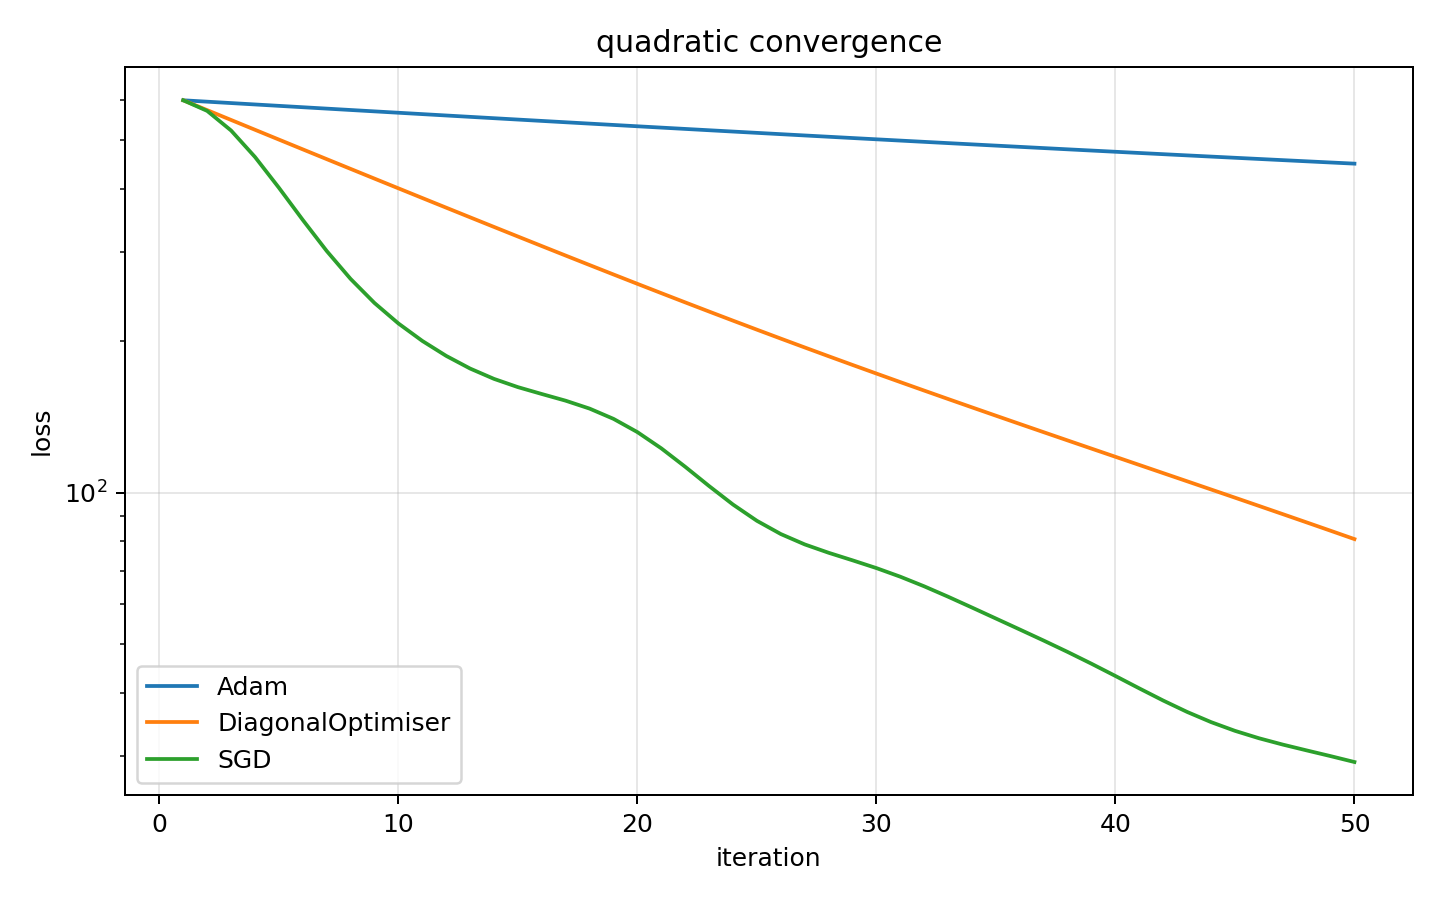

/content/results/synthetic_optimization_smoke/plots/rosenbrock_loss_vs_steps.png


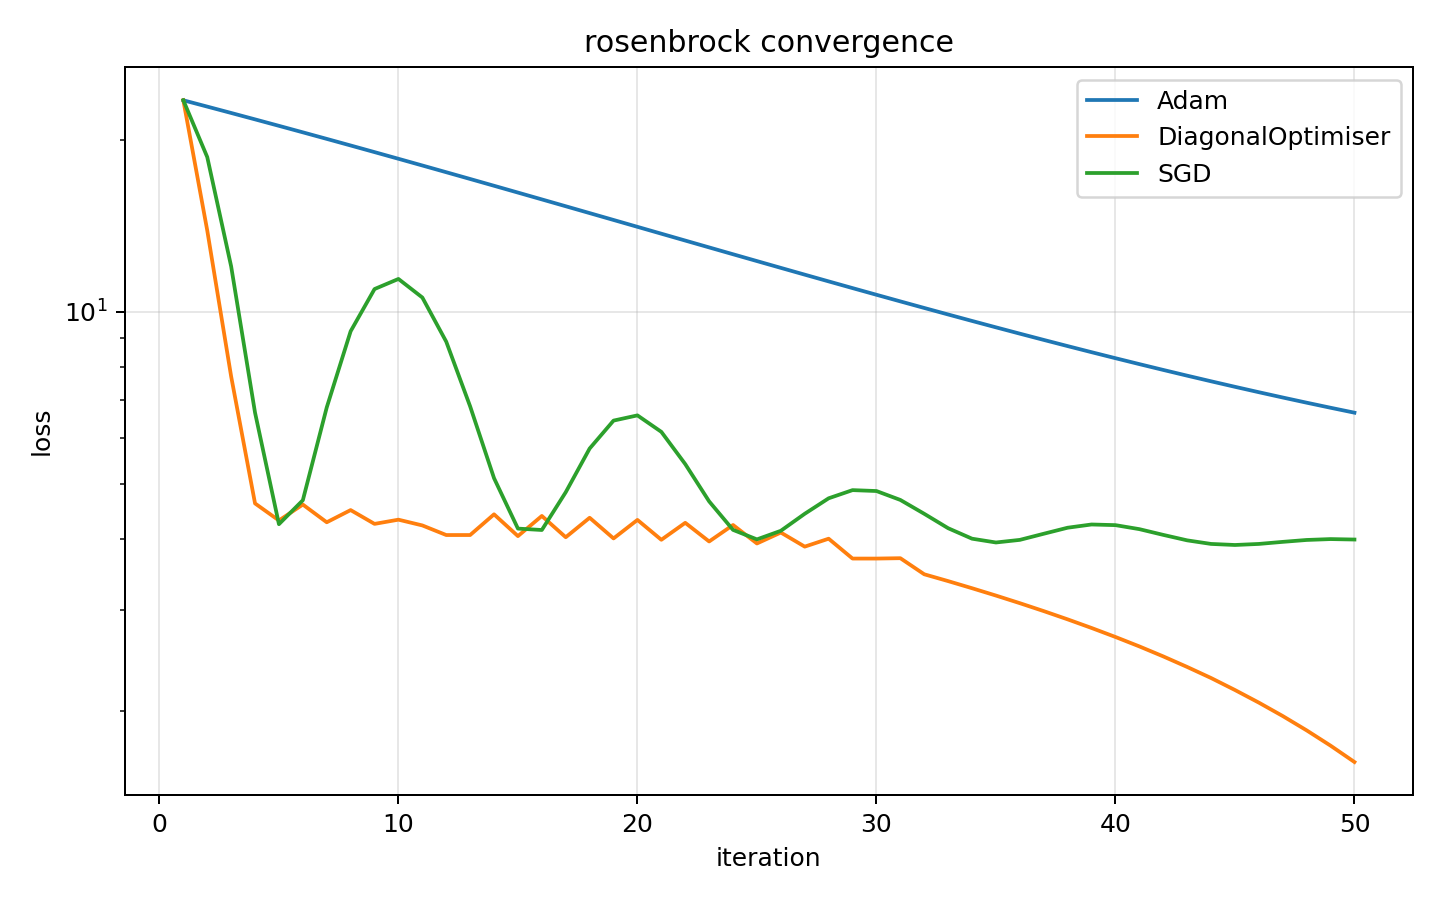

In [16]:
plot_dir = ACTIVE_OUTPUT_DIR / "plots"
if plot_dir.exists():
    plot_files = sorted(plot_dir.glob("*.png"))
    if not plot_files:
        print(f"Plot directory exists but contains no PNG files: {plot_dir}")
    for path in plot_files:
        print(path)
        display(Image(filename=str(path)))
else:
    raise FileNotFoundError(
        f"No plot directory found at {plot_dir}. Run the benchmark cell above to generate plots."
    )

## Interpretation Notes

Report mean +/- standard deviation across seeds. Emphasize convergence, stability, and cost. Do not claim universal superiority from a single condition number or one seed.